In [ ]:
import sounddevice as sd
import numpy as np
from scipy.io.wavfile import read, write

# Read the audio file
sample_rate, audio_data = read('your_audio_file.wav')

# Convert audio data to a NumPy array
audio_array = np.array(audio_data, dtype=np.float32)

# Perform modifications on the audio array (for example, doubling the volume)
modified_audio_array = audio_array * 2.0  # Modify the array as needed

# Convert the modified array back to audio data format
modified_audio_data = modified_audio_array.astype(np.int16)

# Save modified audio as a new WAV file
write('modified_audio.wav', sample_rate, modified_audio_data)

# Play the modified audio
print("Playing modified audio...")
sd.play(modified_audio_data, sample_rate)
sd.wait()  # Wait until the audio is played
print("Audio playback finished.")


In [20]:
import sounddevice as sd
import numpy as np
from scipy.io import wavfile

In [5]:
import sounddevice as sd
import numpy as np

# Settings for recording
duration = 5  # Record for 5 seconds
sample_rate = 44100  # CD quality audio

print("Recording audio...")
audio_data = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1, dtype=np.float32)
sd.wait()  # Wait until recording is finished

print("Recording finished.")




Recording audio...
Recording finished.


In [22]:
# Play the recorded audio
print("Playing recorded audio...")
sd.play(audio_data, sample_rate)
sd.wait()  # Wait until the audio is played
wavfile.write("recorded_audio.wav", sample_rate, audio_data)  # Save as WAV file
print("Audio playback finished.")

Playing recorded audio...
Audio playback finished.


Classical music with noise

In [20]:
import numpy as np
import sounddevice as sd
from scipy.io import wavfile
import pywt

In [23]:


sample_rate, audio_data = wavfile.read('Noise_classical.wav')


In [27]:
# get the first n seconds
n_seconds = 4
audio_data = audio_data[:n_seconds * sample_rate]

# make number of samples 2**k + 3
n_samples = len(audio_data)
n_samples = int(2 ** np.floor(np.log2(n_samples)) + 3)
audio_data = audio_data[:n_samples]


In [40]:
len(audio_data)
mean = np.mean(audio_data)
max_ = np.max(audio_data)
min_ = np.min(audio_data)
standard_deviation = np.std(audio_data)

print("Mean: ", mean)
print("Max: ", max_)
print("Min: ", min_)
print("Standard Deviation: ", standard_deviation)

Mean:  -0.9262864772077055
Max:  4449
Min:  -4024
Standard Deviation:  382.6466450983162


In [35]:
from code.my_functions import denoise
import pywt

low_pass_filter = pywt.Wavelet('db3').dec_lo

# Denoise the audio data
denoised_audio = denoise(audio_data, low_pass_filter, level = 3)
len(denoised_audio)

Playing denoised audio...


In [41]:
mean = np.mean(denoised_audio)
max_ = np.max(denoised_audio)
min_ = np.min(denoised_audio)
standard_deviation = np.std(denoised_audio)

print("Mean: ", mean)
print("Max: ", max_)
print("Min: ", min_)
print("Standard Deviation: ", standard_deviation)

Mean:  -0.9255516917643937
Max:  4422.144275696474
Min:  -3924.997118140582
Standard Deviation:  378.3950516078561


In [45]:
print("Playing original audio...")
sd.play(audio_data, sample_rate)
sd.wait()  # Wait until the audio is played

Playing original audio...


In [46]:
# Play the denoised audio
print("Playing denoised audio...")
sd.play(denoised_audio, sample_rate)
sd.wait()  # Wait until the audio is played

Playing denoised audio...


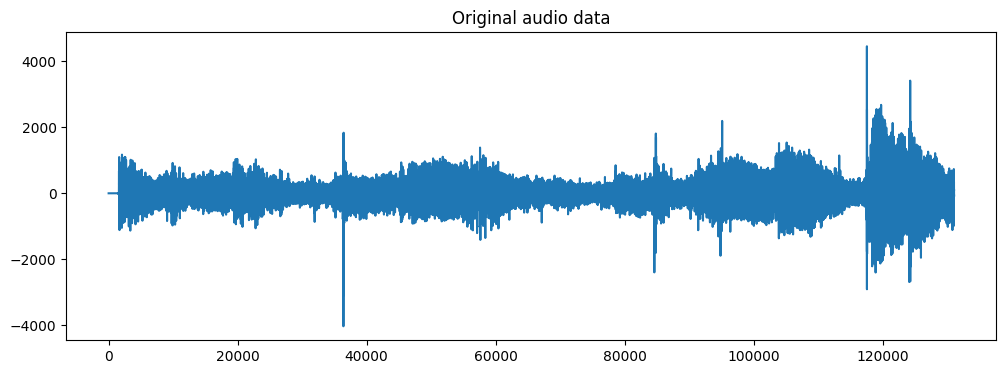

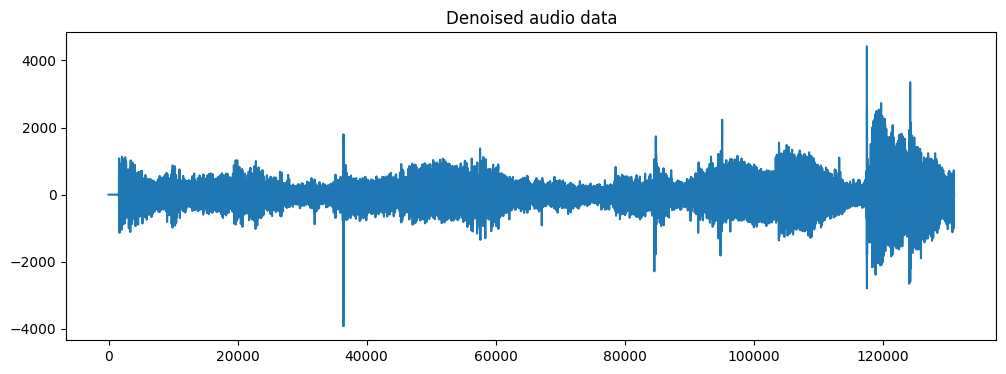

In [47]:
#print oriignal and denoised audio
import matplotlib.pyplot as plt
import numpy as np
import sounddevice as sd
from scipy.io import wavfile
import pywt

sample_rate, audio_data = wavfile.read('Noise_classical.wav')

# get the first n seconds
n_seconds = 4
audio_data = audio_data[:n_seconds * sample_rate]

# make number of samples 2**k + 3

n_samples = len(audio_data)
n_samples = int(2 ** np.floor(np.log2(n_samples)) + 3)
audio_data = audio_data[:n_samples]

low_pass_filter = pywt.Wavelet('db3').dec_lo

# Denoise the audio data
denoised_audio = denoise(audio_data, low_pass_filter, level = 3)

# Plot the original audio data
plt.figure(figsize=(12, 4))
plt.plot(audio_data)
plt.title("Original audio data")

# Plot the denoised audio data
plt.figure(figsize=(12, 4))
plt.plot(denoised_audio)
plt.title("Denoised audio data")

plt.show()

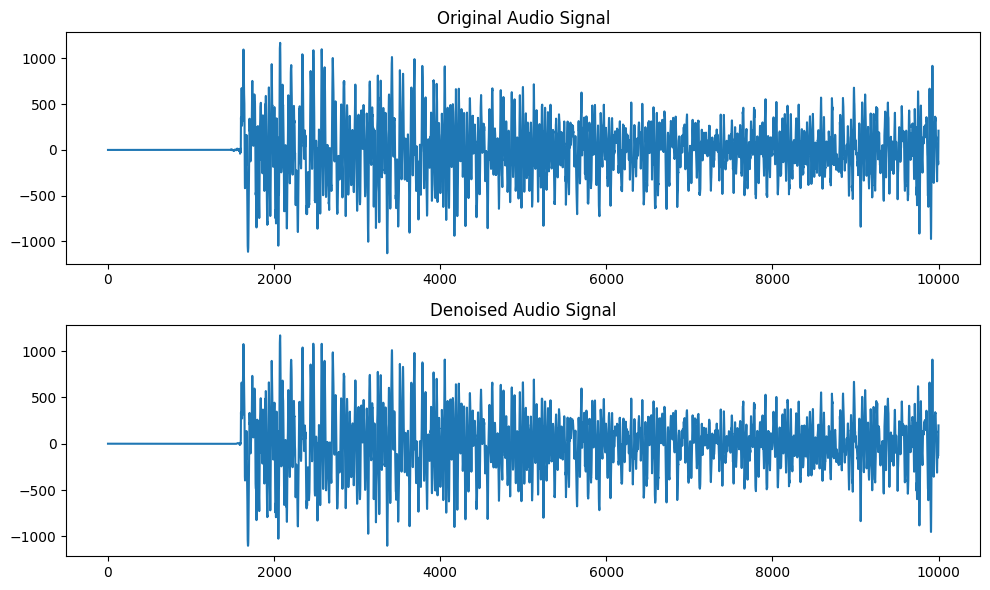